# 01 - Medical infrastructure

Extracts medical facilities around the Hajj holy sites from OpenStreetMap, cleans and
de-duplicates them, and classifies each by type.

**Output:** 216 cleaned medical locations.

In [ ]:
# If needed, uncomment:
# %pip install -U pandas numpy geopandas osmnx folium plotly pyarrow openpyxl

from pathlib import Path
import re
import unicodedata
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import folium
import plotly.express as px
from branca.element import Element

print("OSMnx:", ox.__version__)
print("GeoPandas:", gpd.__version__)
print("Folium:", folium.__version__)


OSMnx: 2.1.1
GeoPandas: 1.1.4
Folium: 0.20.0


## 1. Configuration

The study region is defined as a reproducible point-radius area centred between central
Makkah and the eastern holy sites, rather than depending on a single administrative
boundary. A 25 km radius captures the broader Makkah and Hajj logistics environment;
the operational region is narrowed to the four analytical zones in notebook 02.

In [ ]:
PROJECT_ROOT = Path("hajj_drone_project")
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "osm"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "data" / "model"
MAP_DIR = PROJECT_ROOT / "outputs" / "maps"
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"

for folder in [RAW_DIR, PROCESSED_DIR, MODEL_DIR, MAP_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Approximate central point for the initial Makkah/Hajj study region.
# Coordinates are configuration parameters, not claimed facility locations.
STUDY_CENTER = (21.3891, 39.8579)  # (latitude, longitude)
STUDY_RADIUS_M = 25_000

ox.settings.use_cache = True
ox.settings.log_console = True
ox.settings.requests_timeout = 180

print("Project directory:", PROJECT_ROOT.resolve())
print("Study center:", STUDY_CENTER)
print("Radius (km):", STUDY_RADIUS_M / 1000)


Project directory: C:\Users\firas.hindawi.CCM\Desktop\papers\Drone-Based Data Driven Medical Supply Distribution\hajj-drone-logistics\notebooks\hajj_drone_project
Study center: (21.3891, 39.8579)
Radius (km): 25.0


## 2. OSM feature definitions

OSM tagging is heterogeneous, so the query uses several relevant tag families and
classification is performed after retrieval, since OSMnx returns the union of matching
tags.

Retrieved categories: hospitals, clinics, pharmacies, doctors, ambulance stations,
emergency wards and emergency-tagged healthcare, and healthcare features generally.
The extraction is deliberately broad so that local tagging patterns are visible before
the set is narrowed.

In [ ]:
MEDICAL_TAGS = {
    "amenity": ["hospital", "clinic", "pharmacy", "doctors"],
    "healthcare": True,
    "emergency": ["ambulance_station", "emergency_ward_entrance"],
}

MEDICAL_TAGS


{'amenity': ['hospital', 'clinic', 'pharmacy', 'doctors'],
 'healthcare': True,
 'emergency': ['ambulance_station', 'emergency_ward_entrance']}

## 3. Download medical and emergency features from OpenStreetMap

`features_from_point` is used rather than a named boundary query, so the extraction does
not depend on the exact name or geometry of an administrative area.

In [ ]:
medical_raw = ox.features_from_point(
    STUDY_CENTER,
    tags=MEDICAL_TAGS,
    dist=STUDY_RADIUS_M
)

print(f"Retrieved {len(medical_raw):,} raw OSM features.")
display(medical_raw.head())


Retrieved 216 raw OSM features.


geometry   amenity  \
element id                                                
node    2504820208   POINT (39.8353 21.36121)  pharmacy   
        2504821098  POINT (39.83781 21.36924)  pharmacy   
        2706849553  POINT (39.86872 21.40992)  hospital   
        2708673853  POINT (39.78427 21.40061)  hospital   
        4340644089  POINT (39.78673 21.42375)    clinic   

                                       name                  name:ar  \
element id                                                             
node    2504820208                      دان                      دان   
        2504821098                      دان                      دان   
        2706849553  المستشفى الأهلي السعودي  المستشفى الأهلي السعودي   
        2708673853        مستوصف قضيب البان        مستوصف قضيب البان   
        4340644089      مستوصف هاله بن لادن      مستوصف هاله بن لادن   

                                    name:en addr:city addr:postcode  \
element id                                                            
node    2504820208                      Dan       NaN           NaN   
        2504821098                      Dan       NaN           NaN   
        2706849553  Saudi National Hospital       مكة         24243   
        2708673853                      NaN       NaN           NaN   
        4340644089                      NaN       NaN           NaN   

                      addr:street healthcare                 name:tr  ...  \
element id                                                            ...   
node    2504820208            NaN        NaN                     NaN  ...   
        2504821098            NaN        NaN                     NaN  ...   
        2706849553  شارع العزيزية   hospital  Suudi Ulusal Hastanesi  ...   
        2708673853            NaN   hospital                     NaN  ...   
        4340644089            NaN        NaN                     NaN  ...   

                   payment:credit_cards wheelchair alt_name alt_name:ar  \
element id                                                                
node    2504820208                  NaN        NaN      NaN         NaN   
        2504821098                  NaN        NaN      NaN         NaN   
        2706849553                  NaN        NaN      NaN         NaN   
        2708673853                  NaN        NaN      NaN         NaN   
        4340644089                  NaN        NaN      NaN         NaN   

                   source building addr:place panoramax contact:facebook  \
element id                                                                 
node    2504820208    NaN      NaN        NaN       NaN              NaN   
        2504821098    NaN      NaN        NaN       NaN              NaN   
        2706849553    NaN      NaN        NaN       NaN              NaN   
        2708673853    NaN      NaN        NaN       NaN              NaN   
        4340644089    NaN      NaN        NaN       NaN              NaN   

                   contact:instagram  
element id                            
node    2504820208               NaN  
        2504821098               NaN  
        2706849553               NaN  
        2708673853               NaN  
        4340644089               NaN  

[5 rows x 47 columns]

In [ ]:
# Preserve OSM element type and OSM ID from the multi-index.
medical = medical_raw.reset_index()

# Keep a raw GeoPackage snapshot before transformations.
raw_gpkg = RAW_DIR / "medical_emergency_raw.gpkg"
medical.to_file(raw_gpkg, layer="medical_raw", driver="GPKG")

print("Saved:", raw_gpkg)


Saved: hajj_drone_project\data\raw\osm\medical_emergency_raw.gpkg


## 4. Standardize geometry and coordinates

OSM features can be points, polygons, or multipolygons. Optimization requires one representative coordinate per facility.

For polygons, the notebook calculates a representative point in a projected CRS rather than assuming the polygon centroid is always a valid interior point.


In [ ]:
# Work in WGS84 for storage.
medical = gpd.GeoDataFrame(medical, geometry="geometry", crs=medical_raw.crs)

# Create representative points safely.
projected = medical.to_crs(medical.estimate_utm_crs())
rep_projected = projected.geometry.representative_point()
rep_wgs84 = gpd.GeoSeries(rep_projected, crs=projected.crs).to_crs(4326)

medical["longitude"] = rep_wgs84.x.values
medical["latitude"] = rep_wgs84.y.values

medical[["latitude", "longitude", "geometry"]].head()


,latitude,longitude,geometry
0,21.361206,39.835303,POINT (39.8353 21.36121)
1,21.369241,39.837810,POINT (39.83781 21.36924)
2,21.409918,39.868719,POINT (39.86872 21.40992)
3,21.400606,39.784269,POINT (39.78427 21.40061)
4,21.423750,39.786730,POINT (39.78673 21.42375)


## 5. Standardize facility categories

The category function keeps the raw OSM tags but also produces a compact category suitable for modeling. This is deliberately conservative. Records that cannot yet be confidently classified remain `other_healthcare` or `unclassified`.


In [ ]:
def norm_text(value):
    if pd.isna(value):
        return ""
    return unicodedata.normalize("NFC", str(value)).strip().lower()

def combined_names(row):
    return " ".join(norm_text(row.get(c)) for c in ["name", "name:ar", "name:en"])

def classify_facility(row):
    amenity = norm_text(row.get("amenity"))
    healthcare = norm_text(row.get("healthcare"))
    emergency = norm_text(row.get("emergency"))
    speciality = norm_text(row.get("healthcare:speciality"))
    names = combined_names(row)

    # Hajj-specific refinement
    if "مركز صحي موسمي" in names or "seasonal health" in names:
        return "seasonal_health_center"
    if emergency == "ambulance_station":
        return "ambulance_station"
    if amenity == "hospital" or healthcare == "hospital":
        return "hospital"
    if amenity == "clinic" or healthcare == "clinic":
        return "clinic"
    if amenity == "pharmacy" or healthcare == "pharmacy":
        return "pharmacy"
    if amenity == "doctors" or healthcare in {"doctor", "doctors"}:
        return "doctors"
    if "emergency" in speciality or emergency in {"yes", "emergency_ward_entrance"}:
        return "emergency_medical"
    if healthcare:
        return "other_healthcare"
    return "unclassified"

medical["category"] = medical.apply(classify_facility, axis=1)

medical["name_en"] = medical.get("name:en", pd.Series(index=medical.index, dtype="object"))
medical["name_ar"] = medical.get("name:ar", pd.Series(index=medical.index, dtype="object"))
medical["name"] = medical.get("name", pd.Series(index=medical.index, dtype="object"))

medical["display_name"] = (
    medical["name_en"]
    .fillna(medical["name"])
    .fillna(medical["name_ar"])
    .fillna("Unnamed OSM feature")
)

def clean_map_text(value):
    if pd.isna(value):
        return "Unknown"
    text = unicodedata.normalize("NFC", str(value))
    text = text.replace("`", "'")
    text = "".join(c for c in text if not unicodedata.category(c).startswith("C"))
    return text.strip()

medical["map_name"] = medical["display_name"].apply(clean_map_text)

print(medical["category"].value_counts())
print("Backticks found before cleaning:",
      medical["display_name"].astype(str).str.contains("`", regex=False).sum())


category
pharmacy                  59
hospital                  53
clinic                    52
doctors                   44
seasonal_health_center     5
other_healthcare           2
ambulance_station          1
Name: count, dtype: int64
Backticks found before cleaning: 8


## 6. Build addresses and select research columns


In [ ]:
# IDs, addresses, modeling flags, and final locations table

# Create stable OSM identifiers first.
if "element" not in medical.columns or "id" not in medical.columns:
    raise KeyError(
        "Expected 'element' and 'id' after medical_raw.reset_index(). "
        f"Available columns: {medical.columns.tolist()}"
    )

medical["osm_element"] = medical["element"].astype(str)
medical["osm_id"] = medical["id"]
medical["location_id"] = (
    "OSM_" + medical["osm_element"].str.upper()
    + "_" + medical["osm_id"].astype(str)
)
medical["source"] = "OpenStreetMap"

# Address construction
address_fields = [
    "addr:housenumber", "addr:street", "addr:district",
    "addr:city", "addr:postcode"
]
for col in address_fields:
    if col not in medical.columns:
        medical[col] = np.nan

def make_address(row):
    values = [row.get(c) for c in address_fields]
    values = [str(v).strip() for v in values
              if pd.notna(v) and str(v).strip()]
    return ", ".join(values) if values else np.nan

medical["address"] = medical.apply(make_address, axis=1)

# Preliminary modeling flags
medical["is_medical"] = True
medical["is_emergency"] = medical["category"].isin([
    "hospital", "ambulance_station", "emergency_medical",
    "seasonal_health_center"
])
medical["is_candidate_hub"] = medical["category"].isin([
    "hospital", "ambulance_station", "seasonal_health_center"
])

# Select columns only after all derived fields exist.
keep_columns = [
    "location_id", "osm_element", "osm_id",
    "name", "name_en", "name_ar", "display_name", "map_name",
    "category", "amenity", "healthcare", "emergency",
    "address", "latitude", "longitude", "source",
    "is_medical", "is_emergency", "is_candidate_hub", "geometry"
]
keep_columns = [c for c in keep_columns if c in medical.columns]
locations = medical[keep_columns].copy()

# Remove duplicate OSM objects.
locations = locations.drop_duplicates(
    subset=["osm_element", "osm_id"]
).copy()
locations.reset_index(drop=True, inplace=True)

print("Number of unique locations:", len(locations))
print("\nFacility categories:")
print(locations["category"].value_counts())
display(locations.head())

Number of unique locations: 216

Facility categories:
category
pharmacy                  59
hospital                  53
clinic                    52
doctors                   44
seasonal_health_center     5
other_healthcare           2
ambulance_station          1
Name: count, dtype: int64


,location_id,osm_element,osm_id,name,name_en,name_ar,display_name,map_name,category,amenity,healthcare,emergency,address,latitude,longitude,source,is_medical,is_emergency,is_candidate_hub,geometry
0,OSM_NODE_2504820208,node,2504820208,دان,Dan,دان,Dan,Dan,pharmacy,pharmacy,NaN,NaN,NaN,21.361206,39.835303,OpenStreetMap,True,False,False,POINT (39.8353 21.36121)
1,OSM_NODE_2504821098,node,2504821098,دان,Dan,دان,Dan,Dan,pharmacy,pharmacy,NaN,NaN,NaN,21.369241,39.837810,OpenStreetMap,True,False,False,POINT (39.83781 21.36924)
2,OSM_NODE_2706849553,node,2706849553,المستشفى الأهلي السعودي,Saudi National Hospital,المستشفى الأهلي السعودي,Saudi National Hospital,Saudi National Hospital,hospital,hospital,hospital,NaN,"شارع العزيزية, مكة, 24243",21.409918,39.868719,OpenStreetMap,True,True,True,POINT (39.86872 21.40992)
3,OSM_NODE_2708673853,node,2708673853,مستوصف قضيب البان,NaN,مستوصف قضيب البان,مستوصف قضيب البان,مستوصف قضيب البان,hospital,hospital,hospital,no,NaN,21.400606,39.784269,OpenStreetMap,True,True,True,POINT (39.78427 21.40061)
4,OSM_NODE_4340644089,node,4340644089,مستوصف هاله بن لادن,NaN,مستوصف هاله بن لادن,مستوصف هاله بن لادن,مستوصف هاله بن لادن,clinic,clinic,NaN,NaN,NaN,21.423750,39.786730,OpenStreetMap,True,False,False,POINT (39.78673 21.42375)


## 7. Initial duplicate handling

Duplicate removal in geospatial POI data is not straightforward. Exact duplicate OSM IDs
are removed; likely spatial and name duplicates are flagged rather than deleted, so that
aggressive matching does not discard distinct facilities.

In [ ]:
# Normalized name for duplicate diagnostics.
locations["name_norm"] = (
    locations["display_name"]
    .fillna("")
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Rounded coordinates are only for diagnostics.
locations["lat_round5"] = locations["latitude"].round(5)
locations["lon_round5"] = locations["longitude"].round(5)

locations["possible_duplicate"] = locations.duplicated(
    subset=["name_norm", "lat_round5", "lon_round5"],
    keep=False
)

print("Unique OSM records:", len(locations))
print("Possible duplicate records:", int(locations["possible_duplicate"].sum()))


Unique OSM records: 216
Possible duplicate records: 0


## 8. Basic OSM completeness scoring

This score is an initial research diagnostic, not a validated measure of OSM accuracy.

One point is assigned for each of:
- named feature
- known category
- address present
- coordinates present
- source OSM ID present

The score is normalized to 0-100.


In [ ]:
quality_components = pd.DataFrame(index=locations.index)

quality_components["has_name"] = (
    locations["display_name"].notna()
    & locations["display_name"].ne("Unnamed OSM feature")
)
quality_components["has_category"] = locations["category"].ne("unclassified")
quality_components["has_address"] = locations["address"].notna()
quality_components["has_coordinates"] = (
    locations["latitude"].notna() & locations["longitude"].notna()
)
quality_components["has_osm_id"] = locations["osm_id"].notna()

locations["osm_completeness_score"] = (
    quality_components.sum(axis=1) / quality_components.shape[1] * 100
).round(0).astype(int)

display(
    locations[
        ["display_name", "category", "osm_completeness_score", "possible_duplicate"]
    ].head(20)
)


,display_name,category,osm_completeness_score,possible_duplicate
0,Dan,pharmacy,80,False
1,Dan,pharmacy,80,False
2,Saudi National Hospital,hospital,100,False
3,مستوصف قضيب البان,hospital,80,False
4,مستوصف هاله بن لادن,clinic,80,False
5,Salam Hospital,hospital,80,False
6,مركز صحي العدل,hospital,80,False
7,al-Noor Hospital,hospital,80,False
8,الهلال الأحمر السعودي,clinic,100,False
9,Armed Forces Hospital,hospital,80,False


## 9. Interactive map

Exploratory map for visual inspection of spatial coverage and obvious errors in the
extracted facilities.

In [ ]:
CATEGORY_COLORS = {
    "hospital": "#e41a1c",
    "clinic": "#377eb8",
    "pharmacy": "#4daf4a",
    "doctors": "#00a6d6",
    "ambulance_station": "#984ea3",
    "seasonal_health_center": "#ff7f00",
    "emergency_medical": "#a65628",
    "other_healthcare": "#f781bf",
    "unclassified": "#777777",
}

m = folium.Map(
    location=list(STUDY_CENTER), zoom_start=11,
    tiles="OpenStreetMap", control_scale=True
)

folium.Circle(
    location=list(STUDY_CENTER), radius=STUDY_RADIUS_M,
    color="black", fill=False, weight=2,
    tooltip=f"Initial study region ({STUDY_RADIUS_M/1000:.0f} km radius)"
).add_to(m)

groups = {}
for category in sorted(locations["category"].dropna().unique()):
    groups[category] = folium.FeatureGroup(name=category, show=True)
    groups[category].add_to(m)

for _, row in locations.iterrows():
    category = row["category"]
    color = CATEGORY_COLORS.get(category, "#777777")
    name = clean_map_text(row["map_name"])
    arabic = clean_map_text(row["name_ar"]) if pd.notna(row["name_ar"]) else ""

    popup_html = f'''
    <div style="min-width:250px;font-family:Arial,sans-serif;">
      <b>{name}</b><br>
      <span dir="rtl">{arabic}</span>
      <hr style="margin:6px 0;">
      <b>Category:</b> {category.replace("_"," ").title()}<br>
      <b>OSM ID:</b> {row["osm_id"]}<br>
      <b>OSM completeness score:</b> {row["osm_completeness_score"]}<br>
      <b>Possible duplicate:</b> {row["possible_duplicate"]}<br>
      <b>Coordinates:</b> {row["latitude"]:.6f}, {row["longitude"]:.6f}
    </div>
    '''

    folium.CircleMarker(
        [float(row["latitude"]), float(row["longitude"])],
        radius=6, color=color, fill=True, fill_color=color,
        fill_opacity=0.78, weight=1, tooltip=name,
        popup=folium.Popup(popup_html, max_width=380)
    ).add_to(groups[category])

folium.LayerControl(collapsed=False).add_to(m)

legend_items = ""
for category in sorted(locations["category"].dropna().unique()):
    color = CATEGORY_COLORS.get(category, "#777777")
    label = category.replace("_", " ").title()
    legend_items += (
        f'<div style="margin:3px 0;">'
        f'<span style="display:inline-block;width:12px;height:12px;border-radius:50%;'
        f'background:{color};margin-right:7px;border:1px solid #555;"></span>{label}</div>'
    )

legend_html = f'''
<div style="position:fixed;bottom:30px;left:30px;z-index:9999;
background:white;border:2px solid #777;border-radius:6px;padding:10px 14px;
font-size:13px;box-shadow:0 1px 5px rgba(0,0,0,.35);">
<b>Facility type</b><br>{legend_items}
<div style="margin-top:7px;"><span style="display:inline-block;width:18px;
border-top:2px solid black;margin-right:5px;"></span>Study boundary</div>
</div>
'''
m.get_root().html.add_child(Element(legend_html))

map_path = MAP_DIR / "hajj_medical_facilities_folium_v2.html"
m.save(map_path)
print("Saved Folium map:", map_path)
m


Saved Folium map: hajj_drone_project\outputs\maps\hajj_medical_facilities_folium_v2.html


## 9B. Plotly interactive map

This provides a second, analysis-oriented interactive visualization. Its legend is explicit and interactive: click a facility type to hide/show it.


Saved Plotly map: hajj_drone_project\outputs\maps\hajj_medical_facilities_plotly_v2.html


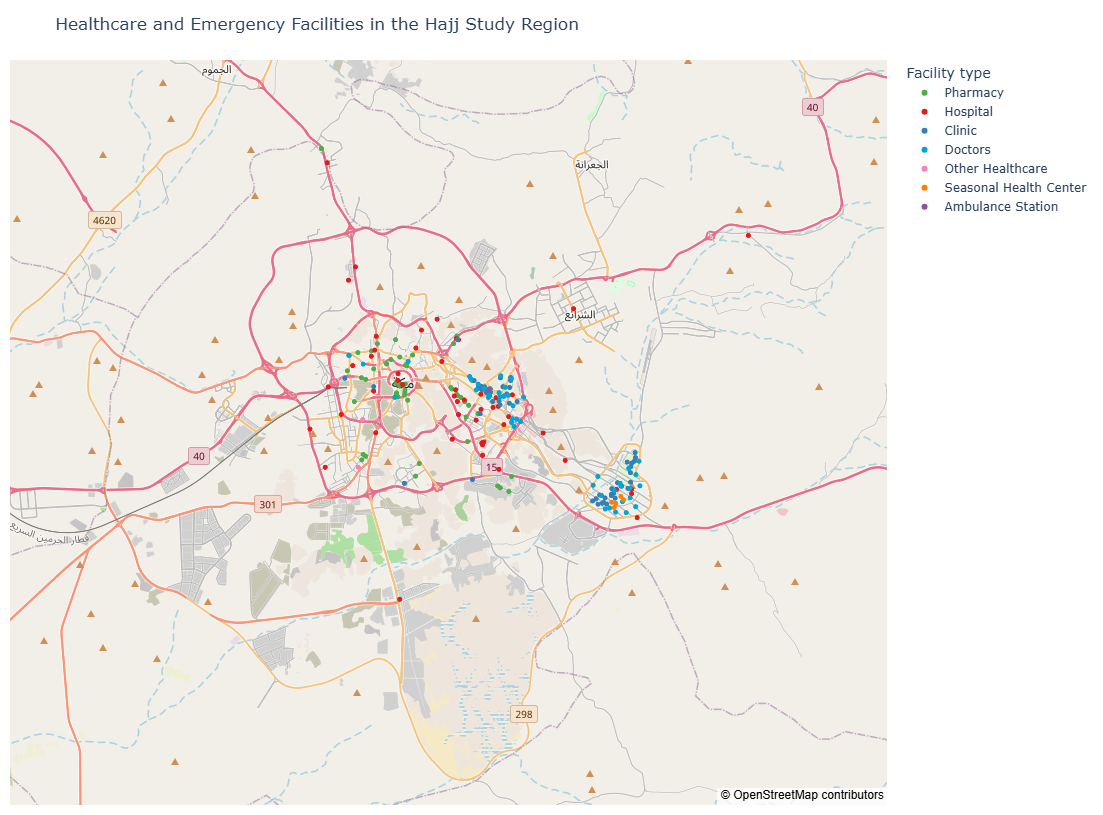

In [ ]:
plot_df = locations.copy()
plot_df["category_label"] = plot_df["category"].str.replace("_", " ", regex=False).str.title()

plot_color_map = {
    k.replace("_", " ").title(): v for k, v in CATEGORY_COLORS.items()
}

fig = px.scatter_map(
    plot_df,
    lat="latitude", lon="longitude",
    color="category_label",
    color_discrete_map=plot_color_map,
    hover_name="map_name",
    hover_data={
        "name_ar": True,
        "category_label": False,
        "osm_completeness_score": True,
        "possible_duplicate": True,
        "latitude": ":.6f",
        "longitude": ":.6f",
    },
    center={"lat": STUDY_CENTER[0], "lon": STUDY_CENTER[1]},
    zoom=10, height=800,
    title="Healthcare and Emergency Facilities in the Hajj Study Region"
)

fig.update_layout(
    map_style="open-street-map",
    legend_title_text="Facility type",
    margin={"r":10,"t":60,"l":10,"b":10}
)

plotly_path = MAP_DIR / "hajj_medical_facilities_plotly_v2.html"
fig.write_html(plotly_path, include_plotlyjs="cdn")
print("Saved Plotly map:", plotly_path)
fig.show()


## 10. Export processed datasets

GeoPackage/GeoJSON preserve geometry. Parquet is preferred for efficient Python analysis. CSV is provided for interoperability with optimization code and manual inspection.


In [ ]:
# Clean helper columns from final exports where appropriate.
export_locations = locations.copy()

gpkg_path = PROCESSED_DIR / "hajj_medical_locations_v1.gpkg"
geojson_path = PROCESSED_DIR / "hajj_medical_locations_v1.geojson"
parquet_path = PROCESSED_DIR / "hajj_medical_locations_v1.parquet"
csv_path = PROCESSED_DIR / "hajj_medical_locations_v1.csv"

export_locations.to_file(gpkg_path, layer="medical_locations", driver="GPKG")
export_locations.to_file(geojson_path, driver="GeoJSON")
export_locations.to_parquet(parquet_path, index=False)

csv_df = pd.DataFrame(export_locations.drop(columns="geometry"))
csv_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("Saved:")
for p in [gpkg_path, geojson_path, parquet_path, csv_path]:
    print(" -", p)


Saved:
 - hajj_drone_project\data\processed\hajj_medical_locations_v1.gpkg
 - hajj_drone_project\data\processed\hajj_medical_locations_v1.geojson
 - hajj_drone_project\data\processed\hajj_medical_locations_v1.parquet
 - hajj_drone_project\data\processed\hajj_medical_locations_v1.csv


## 11. Create baseline demand-point and candidate-hub files

These are candidate modelling inputs. Hospitals, clinics, pharmacies, doctors and
emergency medical features serve as infrastructure references; hospitals and ambulance
stations are flagged as potential hubs. Operational hub feasibility would additionally
depend on land availability, drone operations, regulation, safety and stakeholder
requirements, none of which are represented here.

In [ ]:
# ---------------------------------------------------------
# Export medical infrastructure and preliminary hub pool
# ---------------------------------------------------------

# IMPORTANT:
# These healthcare POIs are infrastructure, NOT final demand points.
medical_infrastructure = locations.copy()

# Preliminary pool only. Final hub eligibility will be evaluated in a later notebook
# using operational, spatial, regulatory, capacity, and suitability criteria.
preliminary_hub_pool = locations[
    locations["category"].isin([
        "hospital",
        "ambulance_station",
        "seasonal_health_center",
        "emergency_medical",
    ])
].copy()

medical_infrastructure.drop(columns="geometry").to_csv(
    MODEL_DIR / "medical_infrastructure_v1.csv",
    index=False,
    encoding="utf-8-sig"
)

preliminary_hub_pool.drop(columns="geometry").to_csv(
    MODEL_DIR / "preliminary_hub_source_pool_v1.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Medical infrastructure records:", len(medical_infrastructure))
print("Preliminary hub-source records:", len(preliminary_hub_pool))
print("\nPreliminary hub-source categories:")
print(preliminary_hub_pool["category"].value_counts())


Medical infrastructure records: 216
Preliminary hub-source records: 59

Preliminary hub-source categories:
category
hospital                  53
seasonal_health_center     5
ambulance_station          1
Name: count, dtype: int64


## 12. Air-distance matrix

Straight-line geodesic (Haversine) distance in kilometres, used throughout as a
first-order approximation of drone travel. It does not account for routing, wind,
restricted airspace or terrain.

In [ ]:
def haversine_matrix(latitudes, longitudes):
    lat = np.radians(np.asarray(latitudes, dtype=float))
    lon = np.radians(np.asarray(longitudes, dtype=float))
    lat1, lat2 = lat[:, None], lat[None, :]
    lon1, lon2 = lon[:, None], lon[None, :]
    dlat, dlon = lat2-lat1, lon2-lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return 6371.0088*c

# Diagnostic pairwise air distances between medical infrastructure points.
# This is NOT the final demand-to-hub distance matrix.
coords = medical_infrastructure[["latitude", "longitude"]].dropna()
ids = medical_infrastructure.loc[coords.index, "location_id"]

D_infrastructure = haversine_matrix(coords["latitude"], coords["longitude"])

np.save(
    MODEL_DIR / "medical_infrastructure_air_distance_matrix_km.npy",
    D_infrastructure
)

distance_df = pd.DataFrame(D_infrastructure, index=ids, columns=ids)
distance_df.to_csv(
    MODEL_DIR / "medical_infrastructure_air_distance_matrix_km.csv"
)

print("Infrastructure distance matrix:", D_infrastructure.shape)
display(distance_df.iloc[:5, :5])


Infrastructure distance matrix: (216, 216)


location_id,OSM_NODE_2504820208,OSM_NODE_2504821098,OSM_NODE_2706849553,OSM_NODE_2708673853,OSM_NODE_4340644089
location_id,,,,,
OSM_NODE_2504820208,0.000000,0.930435,6.427300,6.864181,8.582401
OSM_NODE_2504821098,0.930435,0.000000,5.540733,6.549491,8.043949
OSM_NODE_2706849553,6.427300,5.540733,0.000000,8.803803,8.625469
OSM_NODE_2708673853,6.864181,6.549491,8.803803,0.000000,2.586101
OSM_NODE_4340644089,8.582401,8.043949,8.625469,2.586101,0.000000


## 13. OSM completeness report


In [ ]:
summary = pd.DataFrame({
    "metric": [
        "total_unique_records",
        "named_records",
        "records_with_address",
        "possible_duplicate_records",
        "mean_quality_score",
        "preliminary_hub_source_pool",
    ],
    "value": [
        len(locations),
        int((locations["display_name"] != "Unnamed OSM feature").sum()),
        int(locations["address"].notna().sum()),
        int(locations["possible_duplicate"].sum()),
        round(float(locations["osm_completeness_score"].mean()), 1),
        len(preliminary_hub_pool),
    ]
})

category_summary = (
    locations.groupby("category", dropna=False)
    .agg(
        records=("location_id", "count"),
        named=("display_name", lambda x: (x != "Unnamed OSM feature").sum()),
        mean_quality_score=("osm_completeness_score", "mean"),
        possible_duplicates=("possible_duplicate", "sum"),
    )
    .reset_index()
)

summary.to_csv(REPORT_DIR / "data_quality_summary_v1.csv", index=False)
category_summary.to_csv(REPORT_DIR / "category_summary_v1.csv", index=False)

display(summary)
display(category_summary)


,metric,value
0,total_unique_records,216.0
1,named_records,211.0
2,records_with_address,15.0
3,possible_duplicate_records,0.0
4,mean_quality_score,80.9
5,preliminary_hub_source_pool,59.0


,category,records,named,mean_quality_score,possible_duplicates
0,ambulance_station,1,1,80.000000,0
1,clinic,52,52,80.769231,0
2,doctors,44,44,80.000000,0
3,hospital,53,52,83.396226,0
4,other_healthcare,2,2,80.000000,0
5,pharmacy,59,55,79.661017,0
6,seasonal_health_center,5,5,80.000000,0


In [ ]:
print("PROJECT_ROOT =", PROJECT_ROOT.resolve())
print("PROCESSED_DIR =", PROCESSED_DIR.resolve())

print("\nFiles in processed directory:")
for p in PROCESSED_DIR.glob("*"):
    print(p.name)

PROJECT_ROOT = C:\Users\firas.hindawi.CCM\Desktop\papers\Drone-Based Data Driven Medical Supply Distribution\hajj-drone-logistics\notebooks\hajj_drone_project
PROCESSED_DIR = C:\Users\firas.hindawi.CCM\Desktop\papers\Drone-Based Data Driven Medical Supply Distribution\hajj-drone-logistics\notebooks\hajj_drone_project\data\processed

Files in processed directory:
hajj_medical_locations_v1.csv
hajj_medical_locations_v1.geojson
hajj_medical_locations_v1.gpkg
hajj_medical_locations_v1.parquet
